In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
# The code below is the function that calculates the portfolio return and volatility for a 2-asset portfolio.
def two_asset_portfolio(r1, r2, sigma1, sigma2, rho, weights=None):
    """
    Calculate portfolio return and volatility for two assets.
    
    Parameters:
    - r1, r2: Expected returns of assets 1 and 2
    - sigma1, sigma2: Volatilities (standard deviations) of assets 1 and 2
    - rho: Correlation coefficient between assets 1 and 2
    - weights: Array of weights for asset 1 (asset 2 weight is calculated as 1-w1)
               If None, 100 evenly spaced weights from 0 to 1 are used
    
    Returns:
    - weights: Array of weights for asset 1
    - returns: Expected portfolio returns
    - volatilities: Portfolio volatilities (standard deviations)
    """
    if weights is None:
        # Generate 100 evenly spaced weights from 0 to 1
        weights = np.linspace(0, 1, 100)
    
    # Calculate portfolio returns
    returns = weights * r1 + (1 - weights) * r2
    
    # Calculate portfolio volatilities
    term1 = (weights * sigma1) ** 2
    term2 = ((1 - weights) * sigma2) ** 2
    term3 = 2 * weights * (1 - weights) * sigma1 * sigma2 * rho
    volatilities = np.sqrt(term1 + term2 + term3)
    
    return weights, returns, volatilities

# The code below is the function that plots the efficient frontier for a 2-asset portfolio.
def plot_efficient_frontier_2_assets(r1, r2, sigma1, sigma2, rho, title=None):
    """
    Plot the efficient frontier for a 2-asset portfolio.
    
    Parameters:
    - r1, r2: Expected returns of assets 1 and 2
    - sigma1, sigma2: Volatilities of assets 1 and 2
    - rho: Correlation coefficient between assets 1 and 2
    - title: Optional plot title
    """
    # Generate weights
    weights = np.linspace(0, 1, 100)
    
    # Calculate portfolio metrics
    w, returns, volatilities = two_asset_portfolio(r1, r2, sigma1, sigma2, rho, weights)
    
    # Create plot
    plt.figure(figsize=(12, 8))
    
    # Plot efficient frontier
    plt.scatter(volatilities, returns, c=weights, cmap='viridis', s=50, alpha=0.8)
    
    # Add colorbar to show weights
    colorbar = plt.colorbar()
    colorbar.set_label('Weight of Asset 1')
    
    # Plot individual assets
    plt.scatter(sigma1, r1, c='red', marker='*', s=200, label=f'Asset 1 (Return: {r1:.2%}, Volatility: {sigma1:.2%})')
    plt.scatter(sigma2, r2, c='green', marker='*', s=200, label=f'Asset 2 (Return: {r2:.2%}, Volatility: {sigma2:.2%})')
    
    # Add labels
    plt.title(title or f'Two-Asset Portfolio Efficient Frontier (ρ = {rho:.2f})')
    plt.xlabel('Portfolio Volatility (σ)')
    plt.ylabel('Expected Return (r)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # Annotate selected weights
    for w in [0, 0.25, 0.5, 0.75, 1]:
        idx = int(w * 99)  # Convert weight to index (0 to 99)
        plt.annotate(f'{w:.0%}', 
                     (volatilities[idx], returns[idx]),
                     xytext=(5, 5), 
                     textcoords='offset points',
                     fontsize=9,
                     bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.7))
    
    plt.show()

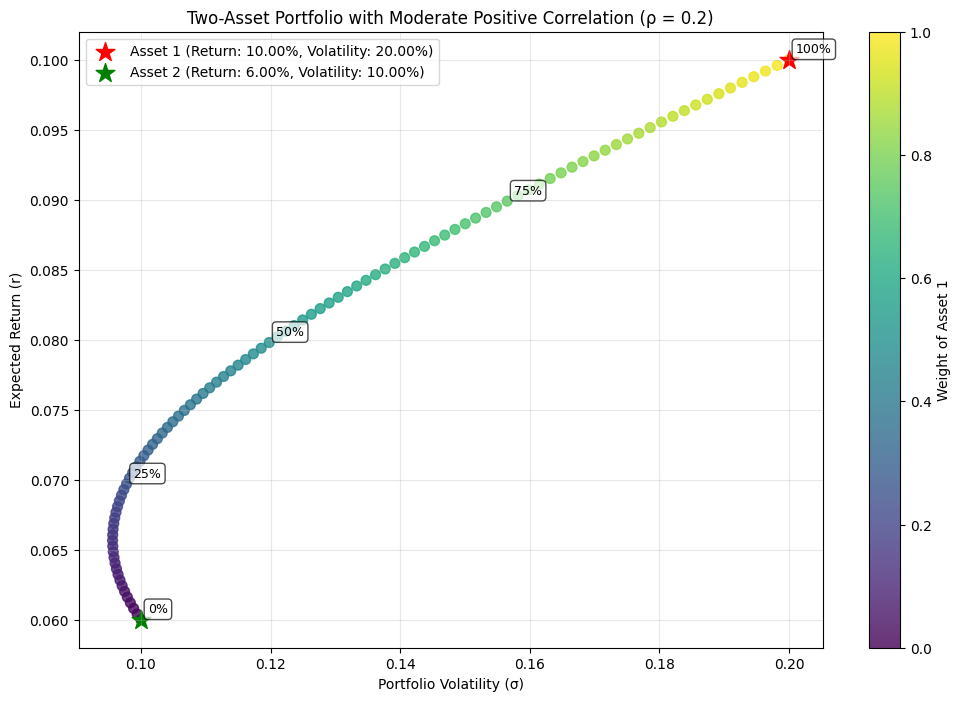

In [9]:
# Example:
r1 = 0.10  # 10% expected return for asset 1
r2 = 0.06  # 6% expected return for asset 2
sigma1 = 0.20  # 20% volatility for asset 1
sigma2 = 0.10  # 10% volatility for asset 2

# Change this value to show students how the efficient frontier changes with different correlation values
corr = 0.2

# Plot efficient frontier with different correlation values ()
plot_efficient_frontier_2_assets(r1, r2, sigma1, sigma2, rho=corr, 
                                title=f'Two-Asset Portfolio with Moderate Positive Correlation (ρ = {corr})')

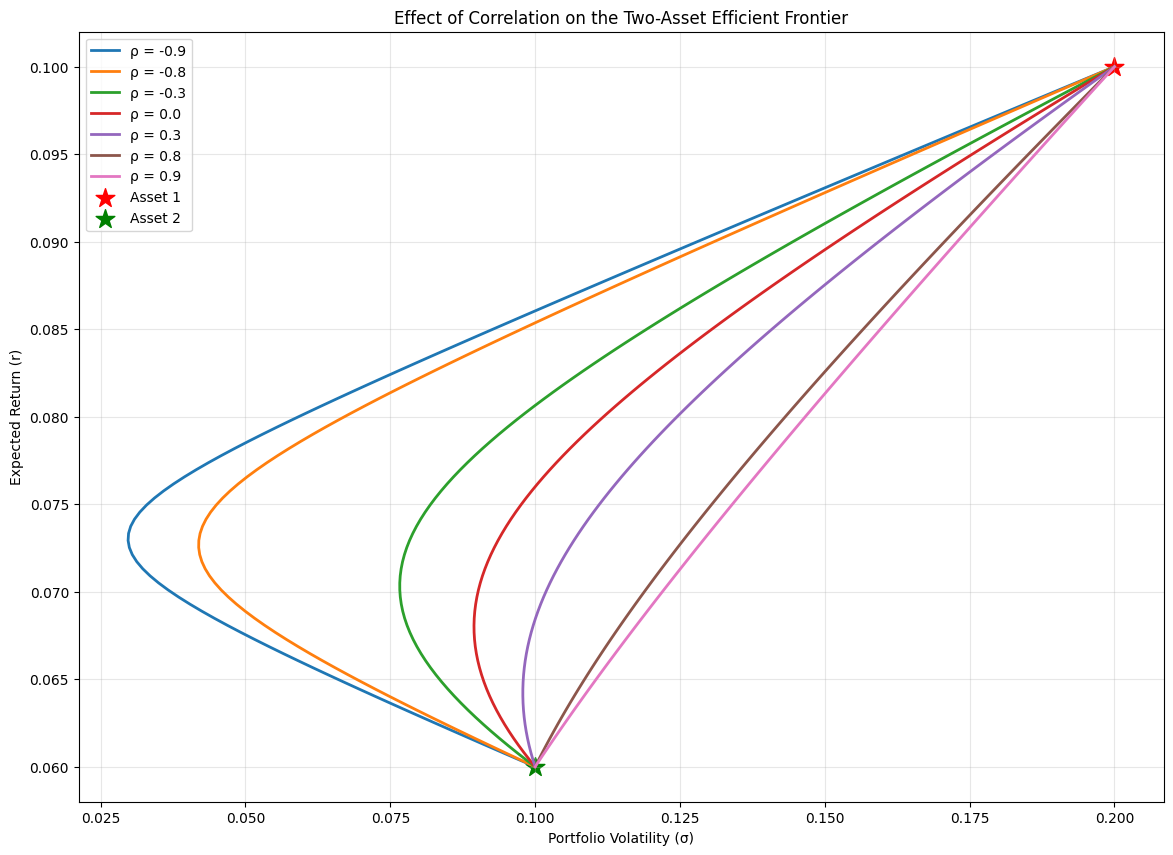

In [10]:
# We will give arbitrary values for the 2-asset correlation coefficients to show how the efficient frontier changes with different correlation values
correlations = [-0.9, -0.8, -0.3, 0, 0.3, 0.8, 0.9]

plt.figure(figsize=(14, 10))

for rho in correlations:
    weights = np.linspace(0, 1, 100)
    _, returns, volatilities = two_asset_portfolio(r1, r2, sigma1, sigma2, rho, weights)
    plt.plot(volatilities, returns, label=f'ρ = {rho:.1f}', linewidth=2)

# Plot individual assets
plt.scatter(sigma1, r1, c='red', marker='*', s=200, label=f'Asset 1')
plt.scatter(sigma2, r2, c='green', marker='*', s=200, label=f'Asset 2')

plt.title('Effect of Correlation on the Two-Asset Efficient Frontier')
plt.xlabel('Portfolio Volatility (σ)')
plt.ylabel('Expected Return (r)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [11]:
def get_weights(num_assets, num_portfolios, style='normalised'):
    """
    Generate portfolio weights according to specified style of sampling.

    Parameters:
    - num_assets (int): Number of assets in the portfolio
    - num_portfolios (int): Number of portfolios to generate
    - style (str): Weight generation style: 'normalised', 'dirichlet', or 'constrain-assets'

    Returns:
    - weights (np.ndarray): A (num_portfolios x num_assets) matrix of portfolio weights
    """

    weights_list = []

    if style == 'normalised':
        for _ in range(num_portfolios):
            w = np.random.random(num_assets)
            w /= np.sum(w)
            weights_list.append(w)

    elif style == 'dirichlet':
        # Uniform sampling over the simplex
        weights_list = np.random.dirichlet(np.ones(num_assets), size=num_portfolios)

    elif style == 'constrain-assets':
        # constrain assets and randomise weights between these 2
        for _ in range(num_portfolios):
            w = np.zeros(num_assets)
            # Randomly choose two distinct asset indices
            i, j = np.random.choice(num_assets, size=2, replace=False)
            # Assign random weights to just those two
            vals = np.random.random(2)
            vals /= np.sum(vals)  # normalise to 1
            w[i], w[j] = vals[0], vals[1]
            weights_list.append(w)

    else:
        raise ValueError("Unsupported style. Choose from 'normalised', 'dirichlet', or 'constrain-assets'.")

    return np.array(weights_list)


In [12]:
class ThreeAssetOptimisation:
    def __init__(self, returns, sigmas, corr_matrix, weighting_style='normalised', num_portfolios=10000):
        self.returns = np.array(returns)
        self.sigmas = np.array(sigmas)
        self.corr_matrix = np.array(corr_matrix)
        self.weighting_style = weighting_style
        self.num_portfolios = num_portfolios
        self.cov_matrix = self._create_covariance_matrix()

    def _create_covariance_matrix(self):
        n = len(self.sigmas)
        cov_matrix = np.zeros((n, n))
        for i in range(n):
            for j in range(n):
                cov_matrix[i, j] = self.sigmas[i] * self.sigmas[j] * self.corr_matrix[i, j]
        return cov_matrix

    def _get_weights(self):
        if self.weighting_style == 'normalised':
            weights = np.random.random((self.num_portfolios, 3))
            weights /= weights.sum(axis=1)[:, np.newaxis]
        elif self.weighting_style == 'dirichlet':
            weights = np.random.dirichlet(np.ones(3), size=self.num_portfolios)
        elif self.weighting_style == 'constrain-asset':
            weights = []
            for _ in range(self.num_portfolios):
                w = np.zeros(3)
                i, j = np.random.choice(3, size=2, replace=False)
                values = np.random.random(2)
                values /= values.sum()
                w[i], w[j] = values[0], values[1]
                weights.append(w)
            weights = np.array(weights)
        else:
            raise ValueError("Unsupported weighting_style. Use 'normalised', 'dirichlet', or 'constrain-asset'.")
        return weights

    def generate_portfolios(self):
        weights = self._get_weights()
        portfolio_returns = weights.dot(self.returns)
        portfolio_vols = np.array([
            np.sqrt(w.T @ self.cov_matrix @ w) for w in weights
        ])
        return weights, portfolio_returns, portfolio_vols

    def plot_efficient_frontier(self):
        weights, portfolio_returns, portfolio_vols = self.generate_portfolios()
        sharpe_ratios = portfolio_returns / portfolio_vols

        # Identify optimal portfolios
        max_sharpe_idx = np.argmax(sharpe_ratios)
        min_vol_idx = np.argmin(portfolio_vols)

        # Plot
        plt.figure(figsize=(14, 10))
        scatter = plt.scatter(portfolio_vols, portfolio_returns, c=sharpe_ratios, cmap='viridis', alpha=0.5, s=10)
        plt.colorbar(scatter).set_label('Sharpe Ratio')

        # Plot individual assets
        for i, (r, s) in enumerate(zip(self.returns, self.sigmas)):
            plt.scatter(s, r, s=200, marker='*', label=f'Asset {i+1} (r={r:.2%}, σ={s:.2%})')

        # Plot optimal portfolios
        plt.scatter(portfolio_vols[max_sharpe_idx], portfolio_returns[max_sharpe_idx], 
                    color='gold', marker='D', s=150, label='Max Sharpe')
        plt.scatter(portfolio_vols[min_vol_idx], portfolio_returns[min_vol_idx], 
                    color='orange', marker='D', s=150, label='Min Volatility')

        plt.title('Three-Asset Portfolio Efficient Frontier')
        plt.xlabel('Portfolio Volatility (σ)')
        plt.ylabel('Expected Return (r)')
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.show()

        # Print portfolio details
        print("Maximum Sharpe Ratio Portfolio:")
        for i, w in enumerate(weights[max_sharpe_idx]):
            print(f"Asset {i+1}: {w:.2%}")
        print()

        print("Minimum Volatility Portfolio:")
        for i, w in enumerate(weights[min_vol_idx]):
            print(f"Asset {i+1}: {w:.2%}")

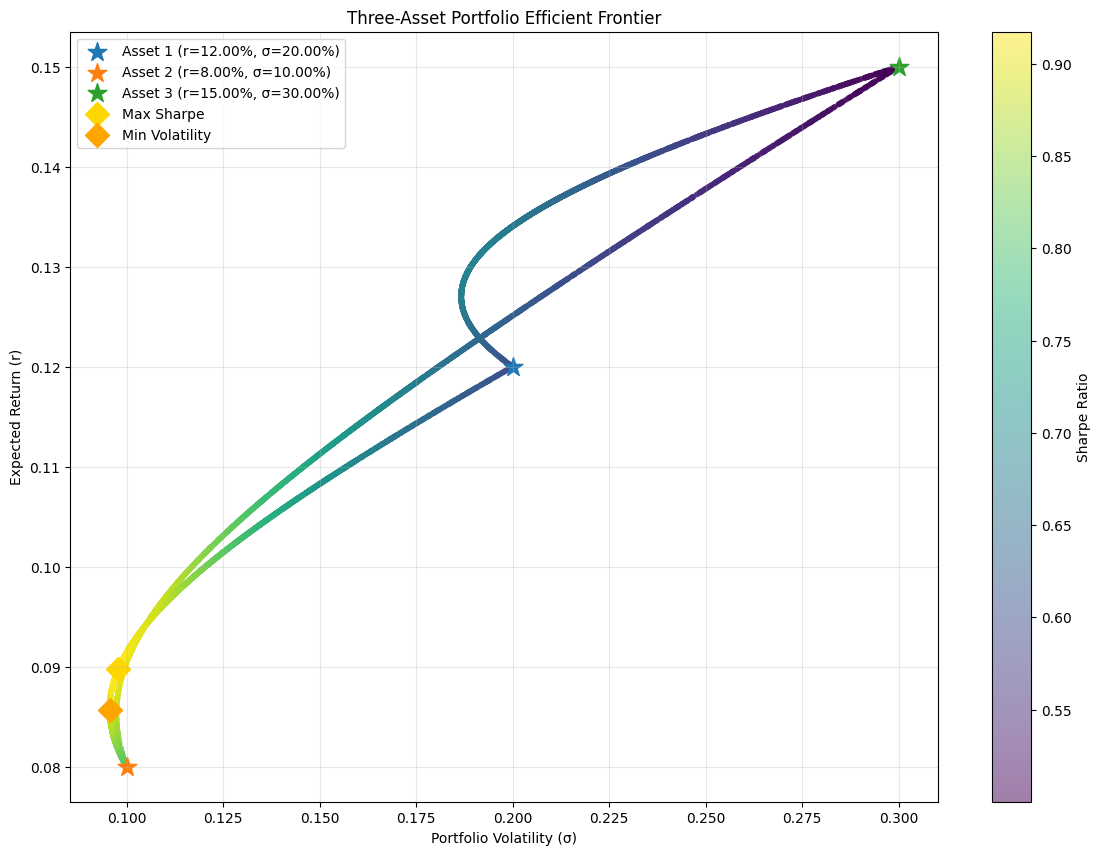

Maximum Sharpe Ratio Portfolio:
Asset 1: 24.43%
Asset 2: 75.57%
Asset 3: 0.00%

Minimum Volatility Portfolio:
Asset 1: 14.24%
Asset 2: 85.76%
Asset 3: 0.00%


In [13]:
# Example parameters for three assets
returns = np.array([0.12, 0.08, 0.15])  # Expected returns
sigmas = np.array([0.20, 0.10, 0.30])  # Volatilities

# Correlation matrix
corr_matrix = np.array([
    [1.0, 0.2, 0.3],  # Correlations with Asset 1
    [0.2, 1.0, 0.1],  # Correlations with Asset 2
    [0.3, 0.1, 1.0]   # Correlations with Asset 3
])

# Instantiate the efficient frontier class
three_asset_optimisation = ThreeAssetOptimisation(returns,sigmas, corr_matrix, weighting_style='constrain-asset')

# Plot the efficient frontier
three_asset_optimisation._create_covariance_matrix()
three_asset_optimisation.generate_portfolios()
three_asset_optimisation.plot_efficient_frontier()

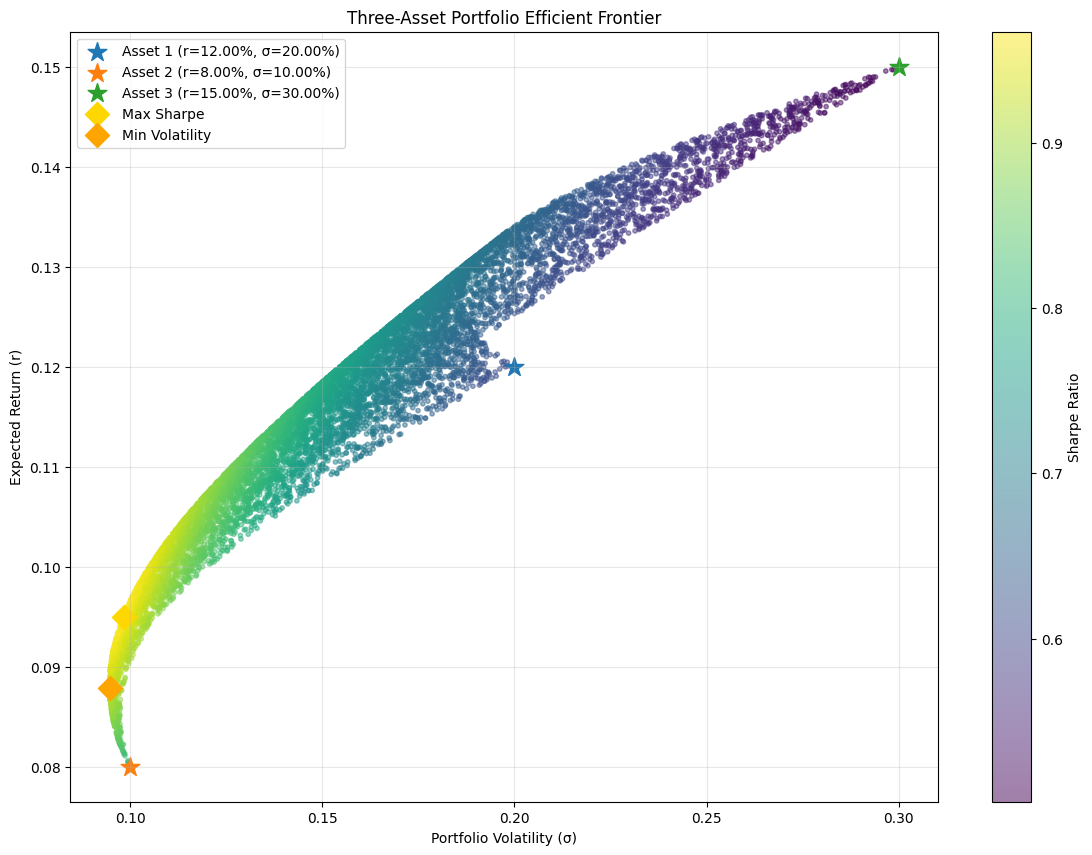

Maximum Sharpe Ratio Portfolio:
Asset 1: 18.65%
Asset 2: 70.56%
Asset 3: 10.78%

Minimum Volatility Portfolio:
Asset 1: 11.99%
Asset 2: 83.68%
Asset 3: 4.33%


In [14]:
# Instantiate a new efficient frontier class
three_asset_optimisation_new_sample = ThreeAssetOptimisation(returns,sigmas, corr_matrix, weighting_style='dirichlet')

# Plot the efficient frontier
three_asset_optimisation_new_sample._create_covariance_matrix()
three_asset_optimisation_new_sample.generate_portfolios()
three_asset_optimisation_new_sample.plot_efficient_frontier()